<div style="
    background: linear-gradient(90deg, #9B111E 0%, #800020 100%);
    color: white;
    padding: 22px;
    border-radius: 16px;
    width: 90%;
    margin: 15px auto;
    text-align: center;
    font-family: 'Bauhaus 93', Arial, sans-serif;
    font-size: 64px;
    font-weight: bold;
    letter-spacing: 0.5px;
    box-shadow: 0 4px 10px rgba(0,0,0,0.15);
">
    🏭 Manufacturing Downtime Analysis
</div>

# 1- Libraries:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 2- Upload Data:

In [2]:
df_ai4i2020 = pd.read_csv("E:\Python\AI4I2020.csv")
df_ai4i2020

,unique_id,product_id,machine_type,brand,location,product_type,air_temperature_K,process_temperature_K,temperature_C,rotational_speed_rpm,...,power_failure,overstain_failure,random_failures,timestamp,operating_hours,downtime_hours,maintenance_type,maintenance_cost,production_units,defect_rate
0,1,M14860,Lathe,GE,Factory_A,Medium,298.1,308.6,24.95,1551,...,0,0,0,2025-01-01 00:00:00,481,0,Preventive,78,207,1.384644
1,2,L47181,CNC,ABB,Factory_A,Low,298.2,308.7,25.05,1408,...,0,0,0,2025-01-01 01:00:00,536,0,Preventive,204,302,2.332453
2,3,L47182,Press,GE,Factory_A,Low,298.1,308.5,24.95,1498,...,0,0,0,2025-01-01 02:00:00,188,0,Preventive,186,206,1.648149
3,4,L47183,Lathe,ABB,Factory_B,Low,298.2,308.6,25.05,1433,...,0,0,0,2025-01-01 03:00:00,704,0,Preventive,207,217,0.398508
4,5,L47184,Lathe,ABB,Factory_C,Low,298.2,308.7,25.05,1408,...,0,0,0,2025-01-01 04:00:00,704,0,Preventive,60,280,1.974006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,CNC,ABB,Factory_A,Medium,298.8,308.4,25.65,1604,...,0,0,0,2026-02-21 11:00:00,406,0,Preventive,93,386,1.254163
9996,9997,H39410,Conveyor,GE,Factory_C,High,298.9,308.4,25.75,1632,...,0,0,0,2026-02-21 12:00:00,942,0,Preventive,286,263,2.826977
9997,9998,M24857,Conveyor,ABB,Factory_A,Medium,299.0,308.6,25.85,1645,...,0,0,0,2026-02-21 13:00:00,295,0,Preventive,228,295,2.715794
9998,9999,H39412,Press,Bosch,Factory_A,High,299.0,308.7,25.85,1408,...,0,0,0,2026-02-21 14:00:00,295,0,Preventive,126,465,1.320512


# 3- Data Exploration:

In [3]:
df_ai4i2020.head()

,unique_id,product_id,machine_type,brand,location,product_type,air_temperature_K,process_temperature_K,temperature_C,rotational_speed_rpm,...,power_failure,overstain_failure,random_failures,timestamp,operating_hours,downtime_hours,maintenance_type,maintenance_cost,production_units,defect_rate
0,1,M14860,Lathe,GE,Factory_A,Medium,298.1,308.6,24.95,1551,...,0,0,0,2025-01-01 00:00:00,481,0,Preventive,78,207,1.384644
1,2,L47181,CNC,ABB,Factory_A,Low,298.2,308.7,25.05,1408,...,0,0,0,2025-01-01 01:00:00,536,0,Preventive,204,302,2.332453
2,3,L47182,Press,GE,Factory_A,Low,298.1,308.5,24.95,1498,...,0,0,0,2025-01-01 02:00:00,188,0,Preventive,186,206,1.648149
3,4,L47183,Lathe,ABB,Factory_B,Low,298.2,308.6,25.05,1433,...,0,0,0,2025-01-01 03:00:00,704,0,Preventive,207,217,0.398508
4,5,L47184,Lathe,ABB,Factory_C,Low,298.2,308.7,25.05,1408,...,0,0,0,2025-01-01 04:00:00,704,0,Preventive,60,280,1.974006


In [4]:
df_ai4i2020.tail()

,unique_id,product_id,machine_type,brand,location,product_type,air_temperature_K,process_temperature_K,temperature_C,rotational_speed_rpm,...,power_failure,overstain_failure,random_failures,timestamp,operating_hours,downtime_hours,maintenance_type,maintenance_cost,production_units,defect_rate
9995,9996,M24855,CNC,ABB,Factory_A,Medium,298.8,308.4,25.65,1604,...,0,0,0,2026-02-21 11:00:00,406,0,Preventive,93,386,1.254163
9996,9997,H39410,Conveyor,GE,Factory_C,High,298.9,308.4,25.75,1632,...,0,0,0,2026-02-21 12:00:00,942,0,Preventive,286,263,2.826977
9997,9998,M24857,Conveyor,ABB,Factory_A,Medium,299.0,308.6,25.85,1645,...,0,0,0,2026-02-21 13:00:00,295,0,Preventive,228,295,2.715794
9998,9999,H39412,Press,Bosch,Factory_A,High,299.0,308.7,25.85,1408,...,0,0,0,2026-02-21 14:00:00,295,0,Preventive,126,465,1.320512
9999,10000,M24859,Conveyor,Bosch,Factory_B,Medium,299.0,308.7,25.85,1500,...,0,0,0,2026-02-21 15:00:00,1039,0,Preventive,293,244,2.033953


In [5]:
df_ai4i2020.shape

(10000, 30)

In [6]:
df_ai4i2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   unique_id                 10000 non-null  int64  
 1   product_id                10000 non-null  object 
 2   machine_type              10000 non-null  object 
 3   brand                     10000 non-null  object 
 4   location                  10000 non-null  object 
 5   product_type              10000 non-null  object 
 6   air_temperature_K         10000 non-null  float64
 7   process_temperature_K     10000 non-null  float64
 8   temperature_C             10000 non-null  float64
 9   rotational_speed_rpm      10000 non-null  int64  
 10  vibration_mm_s            10000 non-null  float64
 11  pressure_bar              10000 non-null  float64
 12  voltage_V                 10000 non-null  float64
 13  current_A                 10000 non-null  float64
 14  torque_

In [7]:
df_ai4i2020.describe().T

,count,mean,std,min,25%,50%,75%,max
unique_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
air_temperature_K,10000.0,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
process_temperature_K,10000.0,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
temperature_C,10000.0,26.854930,2.000259,22.150000,25.150000,26.950000,28.350000,31.350000
rotational_speed_rpm,10000.0,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
vibration_mm_s,10000.0,3.995074,1.071167,-0.207277,3.273504,3.994598,4.732096,8.276090
pressure_bar,10000.0,6.999468,0.537972,5.147761,6.636547,7.001175,7.366082,8.867490
voltage_V,10000.0,219.980549,3.994603,205.889335,217.290421,220.049030,222.657996,234.979056
current_A,10000.0,8.000797,2.034603,0.757647,6.633311,8.037498,9.378794,15.595055
torque_Nm,10000.0,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000


In [8]:
df_ai4i2020.columns

Index(['unique_id', 'product_id', 'machine_type', 'brand', 'location',
       'product_type', 'air_temperature_K', 'process_temperature_K',
       'temperature_C', 'rotational_speed_rpm', 'vibration_mm_s',
       'pressure_bar', 'voltage_V', 'current_A', 'torque_Nm', 'tool_wear_min',
       'machine_failure', 'failure_type', 'tool_wear_failure',
       'heat_dissipation_failure', 'power_failure', 'overstain_failure',
       'random_failures', 'timestamp', 'operating_hours', 'downtime_hours',
       'maintenance_type', 'maintenance_cost', 'production_units',
       'defect_rate'],
      dtype='object')

# 4- Data Preprocessing:

4.1- Data Cleaning:

In [9]:
# Detect Missing Data:
df_ai4i2020.isnull().sum()

unique_id                      0
product_id                     0
machine_type                   0
brand                          0
location                       0
product_type                   0
air_temperature_K              0
process_temperature_K          0
temperature_C                  0
rotational_speed_rpm           0
vibration_mm_s                 0
pressure_bar                   0
voltage_V                      0
current_A                      0
torque_Nm                      0
tool_wear_min                  0
machine_failure                0
failure_type                9661
tool_wear_failure              0
heat_dissipation_failure       0
power_failure                  0
overstain_failure              0
random_failures                0
timestamp                      0
operating_hours                0
downtime_hours                 0
maintenance_type               0
maintenance_cost               0
production_units               0
defect_rate                    0
dtype: int

In [10]:
df_ai4i2020['failure_type']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
9995    NaN
9996    NaN
9997    NaN
9998    NaN
9999    NaN
Name: failure_type, Length: 10000, dtype: object

In [11]:
df_ai4i2020.duplicated().sum()

np.int64(0)

4.2- Feature Selection:

In [12]:
drop_columns = ["unique_id", "product_id", "temperature_C"]

In [13]:
df_ai4i2020_fs = df_ai4i2020.drop(columns=drop_columns)

In [14]:
df_ai4i2020_fs.shape

(10000, 27)

In [15]:
df_ai4i2020_fs.columns

Index(['machine_type', 'brand', 'location', 'product_type',
       'air_temperature_K', 'process_temperature_K', 'rotational_speed_rpm',
       'vibration_mm_s', 'pressure_bar', 'voltage_V', 'current_A', 'torque_Nm',
       'tool_wear_min', 'machine_failure', 'failure_type', 'tool_wear_failure',
       'heat_dissipation_failure', 'power_failure', 'overstain_failure',
       'random_failures', 'timestamp', 'operating_hours', 'downtime_hours',
       'maintenance_type', 'maintenance_cost', 'production_units',
       'defect_rate'],
      dtype='object')

# 5- Exploratory Data Analysis (EDA):

5.1- KPIs:

In [18]:
# =========================================================
# 1. MTBF - Mean Time Between Failures
# Formula:
# SUM(operating_hours) / SUM(machine_failure_flag)
# =========================================================

total_operating_hours = (
    df_ai4i2020_fs["operating_hours"].sum()
)

total_failures = (
    df_ai4i2020_fs["machine_failure"].sum()
)

mtbf = (
    total_operating_hours / total_failures
    if total_failures > 0
    else np.nan
)


# =========================================================
# 2. MTTR - Mean Time To Repair
# Formula:
# SUM(downtime_hours) / SUM(machine_failure_flag)
# =========================================================

total_downtime_hours = (
    df_ai4i2020_fs["downtime_hours"].sum()
)

mttr = (
    total_downtime_hours / total_failures
    if total_failures > 0
    else np.nan
)


# =========================================================
# 3. Cost per Failure
# Formula:
# SUM(maintenance_cost) / SUM(machine_failure_flag)
# =========================================================

total_maintenance_cost = (
    df_ai4i2020_fs["maintenance_cost"].sum()
)

cost_per_failure = (
    total_maintenance_cost / total_failures
    if total_failures > 0
    else np.nan
)


# =========================================================
# 4. Availability
# Formula:
# (SUM(operating_hours) - SUM(downtime_hours))
# / SUM(operating_hours)
# =========================================================

availability = (
    (
        total_operating_hours - total_downtime_hours
    )
    / total_operating_hours
    if total_operating_hours > 0
    else np.nan
)


# =========================================================
# 5. Performance
# Formula:
# AVG(rotational_speed_rpm)
# / MAX(rotational_speed_rpm)
# =========================================================

average_rotational_speed = (
    df_ai4i2020_fs["rotational_speed_rpm"].mean()
)

maximum_rotational_speed = (
    df_ai4i2020_fs["rotational_speed_rpm"].max()
)

performance = (
    average_rotational_speed / maximum_rotational_speed
    if maximum_rotational_speed > 0
    else np.nan
)


# =========================================================
# 6. Good Units
# Formula shown in your image:
# production_units * (1 - defect_rate_decimal)
# =========================================================

df_ai4i2020_fs["good_units"] = (
    df_ai4i2020_fs["production_units"]
    * (
        1 - df_ai4i2020_fs["defect_rate"]
    )
)

total_good_units = (
    df_ai4i2020_fs["good_units"].sum()
)


# =========================================================
# 7. Quality
# Formula:
# SUM(good_units) / SUM(production_units)
# =========================================================

total_production_units = (
    df_ai4i2020_fs["production_units"].sum()
)

quality = (
    total_good_units / total_production_units
    if total_production_units > 0
    else np.nan
)


# =========================================================
# 8. OEE
# Formula:
# Availability * Performance * Quality
# =========================================================

oee = (
    availability
    * performance
    * quality
)


# =========================================================
# Display KPI Results
# =========================================================

kpi_results = pd.DataFrame({
    "KPI": [
        "MTBF",
        "MTTR",
        "Cost per Failure",
        "Availability",
        "Performance",
        "Good Units",
        "Quality",
        "OEE"
    ],

    "Value": [
        f"{mtbf:.1f} h",
        f"{mttr:.1f} h",
        f"{cost_per_failure / 1000:.1f} K",
        f"{availability:.0%}",
        f"{performance:.0%}",
        f"{total_good_units / 1_000_000:.1f} M",
        f"{quality:.0%}",
        f"{oee:.0%}"
    ]
})

# Display final KPI table
kpi_results

,KPI,Value
0,MTBF,43546.6 h
1,MTTR,3.0 h
2,Cost per Failure,5.6 K
3,Availability,100%
4,Performance,53%
5,Good Units,-1.8 M
6,Quality,-53%
7,OEE,-29%


5.2- Analysis:

In [ ]:
# Convert timestamp column to datetime
df_ai4i2020_fs["timestamp"] = pd.to_datetime(df_ai4i2020_fs["timestamp"], errors="coerce")

# Create month number and month name columns
df_ai4i2020_fs["month_number"] = df_ai4i2020_fs["timestamp"].dt.month
df_ai4i2020_fs["month_name"] = df_ai4i2020_fs["timestamp"].dt.month_name()

# Calculate total production units by month
monthly_production = (
    df_ai4i2020_fs.groupby(["month_number", "month_name"], as_index=False)
      ["production_units"]
      .sum()
      .sort_values("month_number")
)

# Rename columns
monthly_production = monthly_production.rename(
    columns={
        "month_name": "Month",
        "production_units": "Total Production Units"
    }
)

# Remove helper column
monthly_production = monthly_production.drop(
    columns="month_number"
)

# Display the result
monthly_production

,Month,Total Production Units
0,January,508920
1,February,395097
2,March,255193
3,April,248472
4,May,259223
5,June,234854
6,July,241639
7,August,254432
8,September,251965
9,October,256229


In [ ]:
# Calculate total maintenance cost by maintenance type
maintenance_cost_analysis = (
    df_ai4i2020_fs
    .groupby("maintenance_type", as_index=False)["maintenance_cost"]
    .sum()
)

# Rename columns
maintenance_cost_analysis = maintenance_cost_analysis.rename(
    columns={
        "maintenance_type": "Maintenance Type",
        "maintenance_cost": "Total Maintenance Cost"
    }
)

# Display the result
maintenance_cost_analysis

,Maintenance Type,Total Maintenance Cost
0,Corrective,219071
1,Preventive,1691481


In [ ]:
# Calculate total maintenance cost by brand
manufacturer_cost_analysis = (
    df_ai4i2020_fs
    .groupby("brand", as_index=False)["maintenance_cost"]
    .sum()
)

# Rename columns
manufacturer_cost_analysis = manufacturer_cost_analysis.rename(
    columns={
        "brand": "Brand",
        "maintenance_cost": "Total Maintenance Cost"
    }
)

# Display the result
manufacturer_cost_analysis

,Brand,Total Maintenance Cost
0,ABB,481045
1,Bosch,465853
2,GE,488800
3,Siemens,474854


In [ ]:
# Calculate total maintenance cost by machine type
machine_cost_analysis = (
    df_ai4i2020_fs
    .groupby("machine_type", as_index=False)["maintenance_cost"]
    .sum()
)

# Rename columns
machine_cost_analysis = machine_cost_analysis.rename(
    columns={
        "machine_type": "Machine Type",
        "maintenance_cost": "Total Maintenance Cost"
    }
)

# Display the result
machine_cost_analysis

,Machine Type,Total Maintenance Cost
0,CNC,479177
1,Conveyor,470811
2,Lathe,480243
3,Press,480321


In [ ]:
# Calculate Sum of Maintenance Cost by Failure Type
failure_cost_analysis = (
    df_ai4i2020_fs
    .groupby("failure_type", as_index=False)["maintenance_cost"]
    .sum()
)

# Set the exact order shown in the Excel Pivot Table
failure_order = [
    "None",
    "Overheat",
    "Overstrain",
    "Power",
    "Unknown",
    "Wear"
]

failure_cost_analysis["failure_type"] = pd.Categorical(
    failure_cost_analysis["failure_type"],
    categories=failure_order,
    ordered=True
)

# Sort by the required order
failure_cost_analysis = (
    failure_cost_analysis
    .sort_values("failure_type")
    .reset_index(drop=True)
)

# Calculate Grand Total
grand_total = failure_cost_analysis["maintenance_cost"].sum()

# Function to format values as K or M
def format_cost(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create formatted cost column
failure_cost_analysis["Formatted Cost"] = (
    failure_cost_analysis["maintenance_cost"]
    .apply(format_cost)
)

# Create final result
result = failure_cost_analysis[
    ["failure_type", "Formatted Cost"]
].rename(
    columns={
        "failure_type": "Failure Type",
        "Formatted Cost": "Sum of Maintenance Cost"
    }
)

# Display result
result

,Failure Type,Sum of Maintenance Cost
0,Overheat,74.3 K
1,Overstrain,50.0 K
2,Power,60.0 K
3,Unknown,6.1 K
4,Wear,28.7 K


In [ ]:
# Calculate Sum of Downtime Hours by Type
downtime_analysis = (
    df_ai4i2020_fs
    .groupby("product_type", as_index=False)["downtime_hours"]
    .sum()
)

# Set the exact order shown in the Excel Pivot Table
type_order = [
    "High",
    "Low",
    "Medium"
]

# Apply categorical order
downtime_analysis["product_type"] = pd.Categorical(
    downtime_analysis["product_type"],
    categories=type_order,
    ordered=True
)

# Sort by the required order
downtime_analysis = (
    downtime_analysis
    .sort_values("product_type")
    .reset_index(drop=True)
)

# Calculate Grand Total
grand_total = downtime_analysis["downtime_hours"].sum()

# Rename columns
result = downtime_analysis.rename(
    columns={
        "product_type": "Type",
        "downtime_hours": "Sum of Downtime Hours"
    }
)

# Display result
result

,Type,Sum of Downtime Hours
0,High,68
1,Low,719
2,Medium,239


In [ ]:
# Calculate Sum of Production Units by Machine Type
machine_production_analysis = (
    df_ai4i2020_fs
    .groupby("machine_type", as_index=False)["production_units"]
    .sum()
)

# Set the exact order shown in the Excel Pivot Table
machine_order = [
    "CNC",
    "Conveyor",
    "Lathe",
    "Press"
]

# Apply categorical order
machine_production_analysis["machine_type"] = pd.Categorical(
    machine_production_analysis["machine_type"],
    categories=machine_order,
    ordered=True
)

# Sort by the required order
machine_production_analysis = (
    machine_production_analysis
    .sort_values("machine_type")
    .reset_index(drop=True)
)

# Calculate Grand Total
grand_total = machine_production_analysis[
    "production_units"
].sum()

# Function to format values as K or M
def format_units(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create formatted values
machine_production_analysis["Formatted Production"] = (
    machine_production_analysis["production_units"]
    .apply(format_units)
)

# Create final result
result = machine_production_analysis[
    ["machine_type", "Formatted Production"]
].rename(
    columns={
        "machine_type": "Machine Type",
        "Formatted Production": "Sum of Production Units"
    }
)

# Display result
result

,Machine Type,Sum of Production Units
0,CNC,860.1 K
1,Conveyor,843.9 K
2,Lathe,862.0 K
3,Press,848.1 K


In [ ]:
# Replace Siemens with Conveyor in the brand column
df_ai4i2020_fs["brand"] = (
    df_ai4i2020_fs["brand"]
    .replace("Siemens", "Conveyor")
)

# Calculate Sum of Production Units by Manufacturer
manufacturer_production_analysis = (
    df_ai4i2020_fs
    .groupby("brand", as_index=False)["production_units"]
    .sum()
)

# Set the exact order
manufacturer_order = [
    "ABB",
    "Bosch",
    "GE",
    "Conveyor"
]

# Apply categorical order
manufacturer_production_analysis["brand"] = pd.Categorical(
    manufacturer_production_analysis["brand"],
    categories=manufacturer_order,
    ordered=True
)

# Sort by the required order
manufacturer_production_analysis = (
    manufacturer_production_analysis
    .sort_values("brand")
    .reset_index(drop=True)
)

# Calculate Grand Total
grand_total = manufacturer_production_analysis[
    "production_units"
].sum()

# Function to format values as K or M
def format_units(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create formatted values
manufacturer_production_analysis["Formatted Production"] = (
    manufacturer_production_analysis["production_units"]
    .apply(format_units)
)

# Create final result
result = manufacturer_production_analysis[
    ["brand", "Formatted Production"]
].rename(
    columns={
        "brand": "Manufacturer",
        "Formatted Production": "Sum of Production Units"
    }
)

# Display result
result

,Manufacturer,Sum of Production Units
0,ABB,851.5 K
1,Bosch,851.7 K
2,GE,865.8 K
3,Conveyor,845.0 K


In [21]:
# Select numeric columns
numeric_data = df_ai4i2020_fs[[
    "air_temperature_K",
    "process_temperature_K",
    "rotational_speed_rpm",
    "vibration_mm_s",
    "pressure_bar",
    "voltage_V",
    "current_A",
    "torque_Nm",
    "tool_wear_min",
    "operating_hours",
    "maintenance_cost",
    "production_units",
    "defect_rate"
]]

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Display correlation matrix
correlation_matrix

,air_temperature_K,process_temperature_K,rotational_speed_rpm,vibration_mm_s,pressure_bar,voltage_V,current_A,torque_Nm,tool_wear_min,operating_hours,maintenance_cost,production_units,defect_rate
air_temperature_K,1.000000,0.876107,0.022670,-0.012064,-0.010687,0.005474,-0.012884,-0.013778,0.013853,0.015035,0.056669,-0.026967,0.040062
process_temperature_K,0.876107,1.000000,0.019277,-0.015364,-0.009204,-0.005080,-0.013348,-0.014061,0.013488,0.014796,0.026133,-0.012786,0.021460
rotational_speed_rpm,0.022670,0.019277,1.000000,-0.814283,-0.811619,0.022820,-0.858058,-0.875027,0.000223,-0.000217,-0.018833,-0.000429,-0.016963
vibration_mm_s,-0.012064,-0.015364,-0.814283,1.000000,0.864904,-0.014598,0.910096,0.928329,-0.002457,-0.003136,0.119624,-0.058764,0.077764
pressure_bar,-0.010687,-0.009204,-0.811619,0.864904,1.000000,-0.013771,0.910186,0.929240,0.002959,0.005152,0.111318,-0.054990,0.081286
voltage_V,0.005474,-0.005080,0.022820,-0.014598,-0.013771,1.000000,-0.010484,-0.012573,-0.002300,-0.005725,0.008939,-0.012370,0.013831
current_A,-0.012884,-0.013348,-0.858058,0.910096,0.910186,-0.010484,1.000000,0.980302,-0.004364,-0.004453,0.121281,-0.059152,0.083206
torque_Nm,-0.013778,-0.014061,-0.875027,0.928329,0.929240,-0.012573,0.980302,1.000000,-0.003093,-0.002838,0.126080,-0.060895,0.085411
tool_wear_min,0.013853,0.013488,0.000223,-0.002457,0.002959,-0.002300,-0.004364,-0.003093,1.000000,0.939111,0.064911,-0.056477,0.063885
operating_hours,0.015035,0.014796,-0.000217,-0.003136,0.005152,-0.005725,-0.004453,-0.002838,0.939111,1.000000,0.062333,-0.054266,0.062596


# 6- Data Visualization:

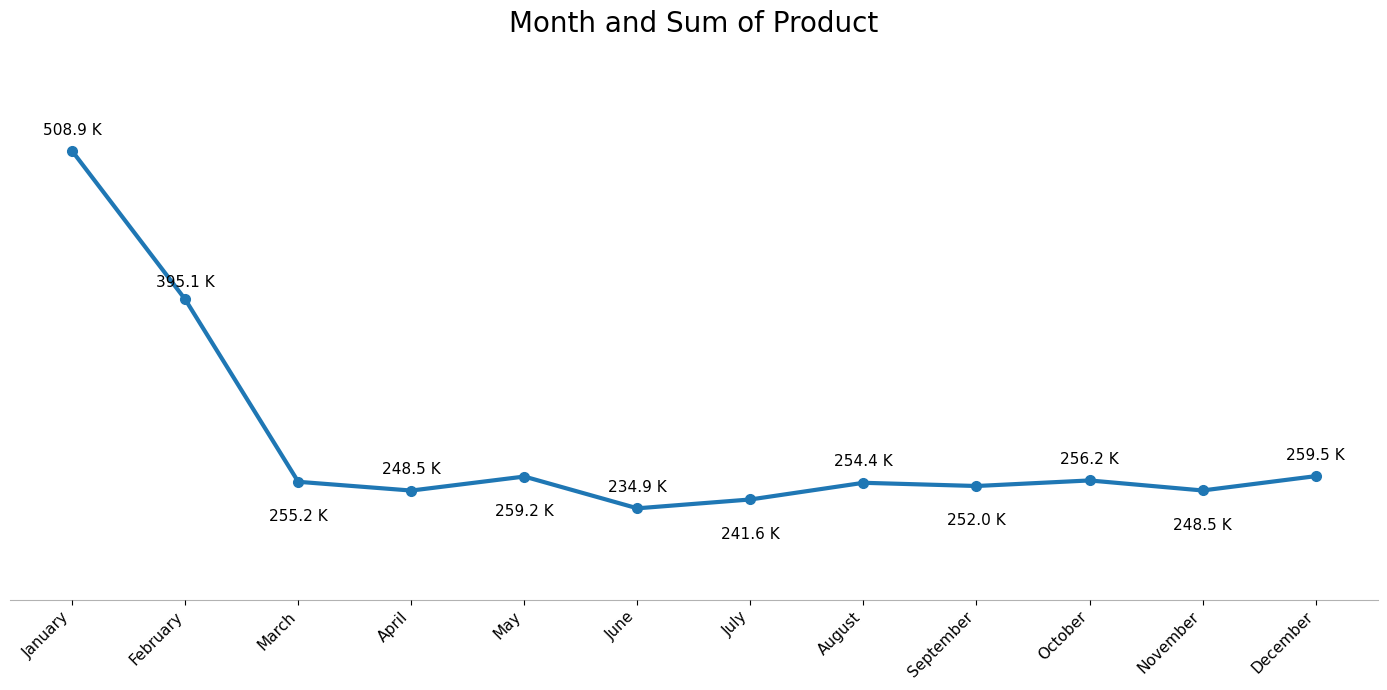

In [ ]:
# Convert timestamp to datetime
df_ai4i2020_fs["timestamp"] = pd.to_datetime(
    df_ai4i2020_fs["timestamp"],
    errors="coerce"
)

# Extract month number and month name
df_ai4i2020_fs["month_number"] = (
    df_ai4i2020_fs["timestamp"].dt.month
)

df_ai4i2020_fs["Month"] = (
    df_ai4i2020_fs["timestamp"].dt.month_name()
)

# Calculate total production units by month
monthly_production = (
    df_ai4i2020_fs
    .groupby(["month_number", "Month"])["production_units"]
    .sum()
    .reset_index()
    .sort_values("month_number")
)

# Convert production units to thousands (K)
monthly_production["Production_K"] = (
    monthly_production["production_units"] / 1000
)

# Create the figure
plt.figure(figsize=(14, 7))

# Create line chart with circular markers
plt.plot(
    monthly_production["Month"],
    monthly_production["Production_K"],
    marker="o",
    linewidth=3,
    markersize=7
)

# Label positions:
# positive = above the point
# negative = below the point
label_offsets = [
    15,    # January
    12,    # February
    -25,   # March
    15,    # April
    -25,   # May
    15,    # June
    -25,   # July
    15,    # August
    -25,   # September
    15,    # October
    -25,   # November
    15     # December
]

# Add value labels
for i, value in enumerate(
    monthly_production["Production_K"]
):
    plt.annotate(
        f"{value:.1f} K",
        xy=(i, value),
        xytext=(0, label_offsets[i]),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11
    )

# Add chart title
plt.title(
    "Month and Sum of Product",
    fontsize=20,
    pad=20
)

# Rotate month names
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=11
)

# Hide Y-axis labels and ticks
plt.yticks([])

# Hide axis labels
plt.xlabel("")
plt.ylabel("")

# Remove grid
plt.grid(False)

# Hide unnecessary borders
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Keep a light bottom axis line
ax.spines["bottom"].set_alpha(0.3)

# Add vertical space for labels
plt.ylim(
    monthly_production["Production_K"].min() - 70,
    monthly_production["Production_K"].max() + 70
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

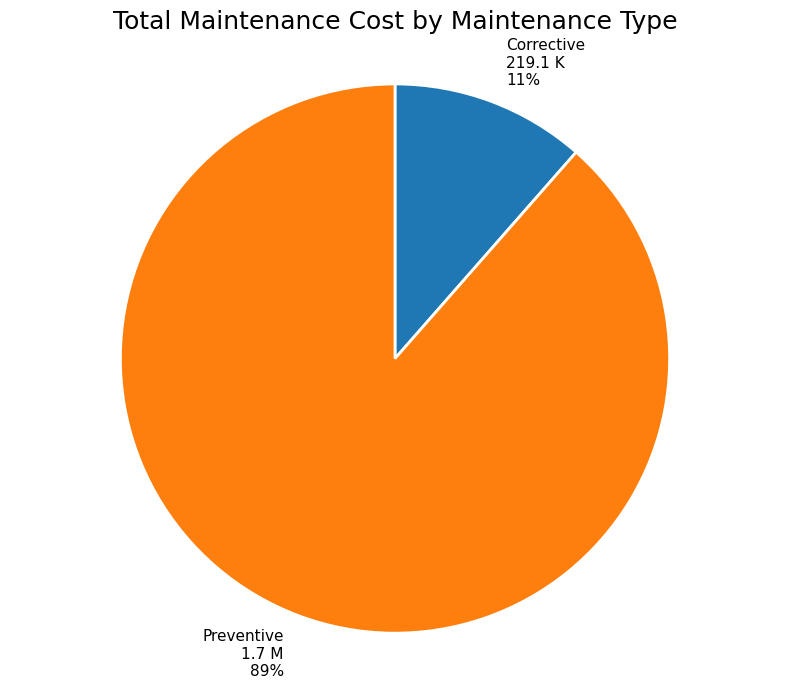

In [ ]:
# Calculate total maintenance cost by maintenance type
maintenance_cost_analysis = (
    df_ai4i2020_fs
    .groupby("maintenance_type")["maintenance_cost"]
    .sum()
    .reset_index()
)

# Extract labels and values
labels = maintenance_cost_analysis["maintenance_type"]
values = maintenance_cost_analysis["maintenance_cost"]

# Function to format values as K or M
def format_cost(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create labels containing:
# Maintenance Type + Cost + Percentage
total = values.sum()

pie_labels = [
    f"{label}\n{format_cost(value)}\n{value / total * 100:.0f}%"
    for label, value in zip(labels, values)
]

# Create the pie chart
plt.figure(figsize=(8, 7))

plt.pie(
    values,
    labels=pie_labels,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 11
    },
    labeldistance=1.15
)

# Add chart title
plt.title(
    "Total Maintenance Cost by Maintenance Type",
    fontsize=18,
    pad=20
)

# Keep the pie circular
plt.axis("equal")

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

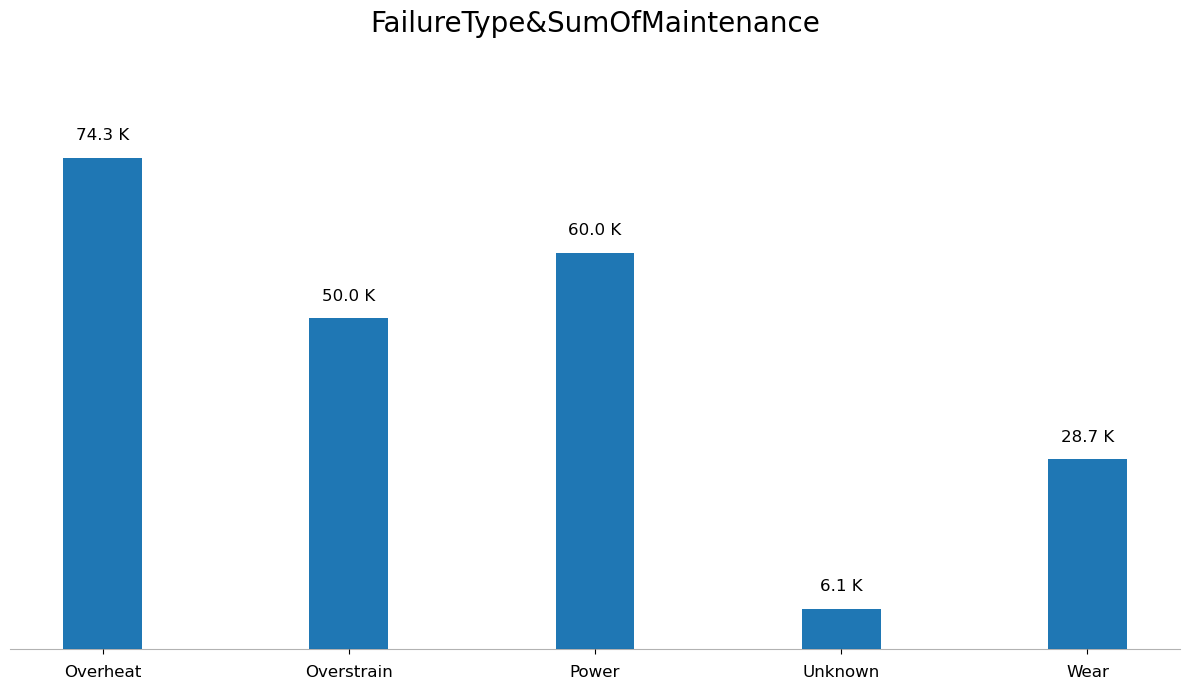

In [ ]:
# Calculate Sum of Maintenance Cost by Failure Type
failure_cost_analysis = (
    df_ai4i2020_fs
    .groupby("failure_type", as_index=False)["maintenance_cost"]
    .sum()
)

# Set exact category order
failure_order = [
    "None",
    "Overheat",
    "Overstrain",
    "Power",
    "Unknown",
    "Wear"
]

failure_cost_analysis["failure_type"] = pd.Categorical(
    failure_cost_analysis["failure_type"],
    categories=failure_order,
    ordered=True
)

# Sort categories
failure_cost_analysis = (
    failure_cost_analysis
    .sort_values("failure_type")
    .reset_index(drop=True)
)

# Extract labels and actual values
labels = failure_cost_analysis["failure_type"].astype(str)
values = failure_cost_analysis["maintenance_cost"]

# Function to format labels as K or M
def format_cost(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart
bars = ax.bar(
    labels,
    values,
    width=0.32
)

# Add value labels above bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.03,
        format_cost(value),
        ha="center",
        va="bottom",
        fontsize=12
    )

# Add chart title
ax.set_title(
    "Failure Type and Sum of Maintenance",
    fontsize=20,
    pad=20
)

# Hide Y-axis ticks and labels
ax.set_yticks([])

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Remove grid
ax.grid(False)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis line lighter
ax.spines["bottom"].set_alpha(0.3)

# Add space above bars for labels
ax.set_ylim(
    0,
    values.max() * 1.20
)

# Format X-axis labels
ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

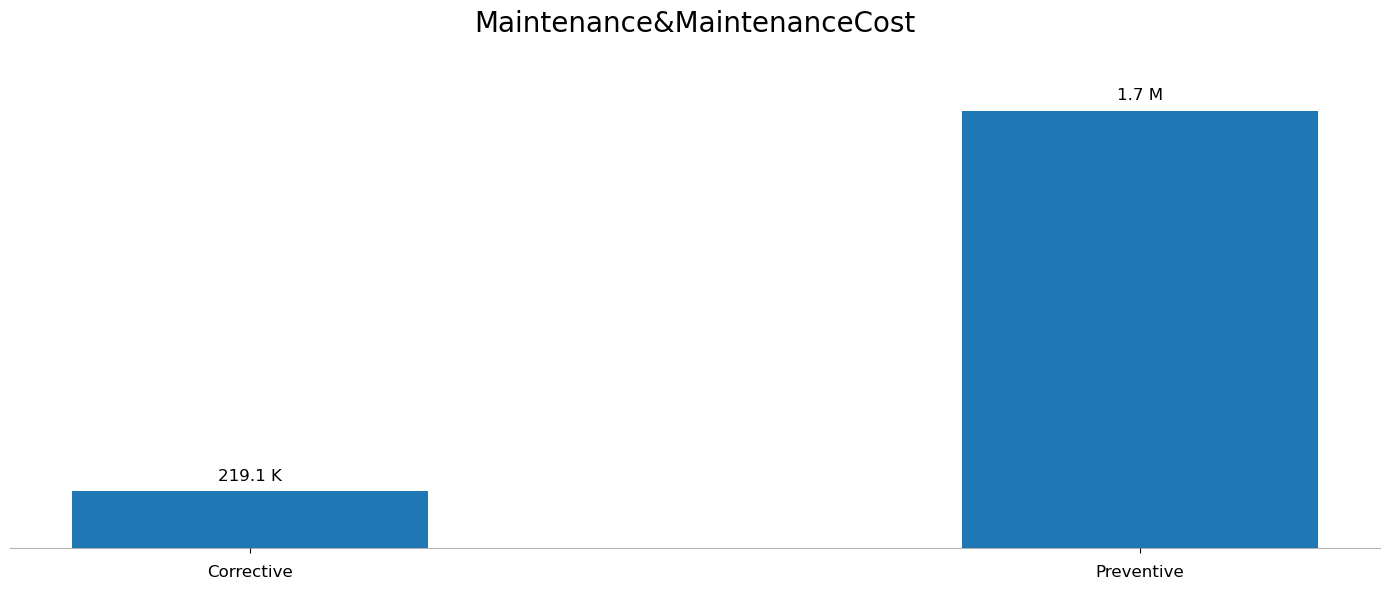

In [ ]:
# Calculate Sum of Maintenance Cost by Maintenance Type
maintenance_cost_analysis = (
    df_ai4i2020_fs
    .groupby("maintenance_type", as_index=False)["maintenance_cost"]
    .sum()
)

# Set the exact order shown in the chart
maintenance_order = [
    "Corrective",
    "Preventive"
]

# Reorder the data
maintenance_cost_analysis = (
    maintenance_cost_analysis
    .set_index("maintenance_type")
    .reindex(maintenance_order)
    .reset_index()
)

# Extract labels and actual values
labels = maintenance_cost_analysis["maintenance_type"]
values = maintenance_cost_analysis["maintenance_cost"]

# Function to format values as K or M
def format_cost(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f} M"
    elif value >= 1_000:
        return f"{value / 1_000:.1f} K"
    return f"{value:.1f}"

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Create bar chart
bars = ax.bar(
    labels,
    values,
    width=0.40
)

# Add value labels above each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.02,
        format_cost(value),
        ha="center",
        va="bottom",
        fontsize=12
    )

# Add chart title
ax.set_title(
    "Maintenance and Maintenance Cost",
    fontsize=20,
    pad=20
)

# Hide Y-axis ticks and labels
ax.set_yticks([])

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Remove grid
ax.grid(False)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis line lighter
ax.spines["bottom"].set_alpha(0.3)

# Add space above the tallest bar
ax.set_ylim(
    0,
    values.max() * 1.12
)

# Format X-axis labels
ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

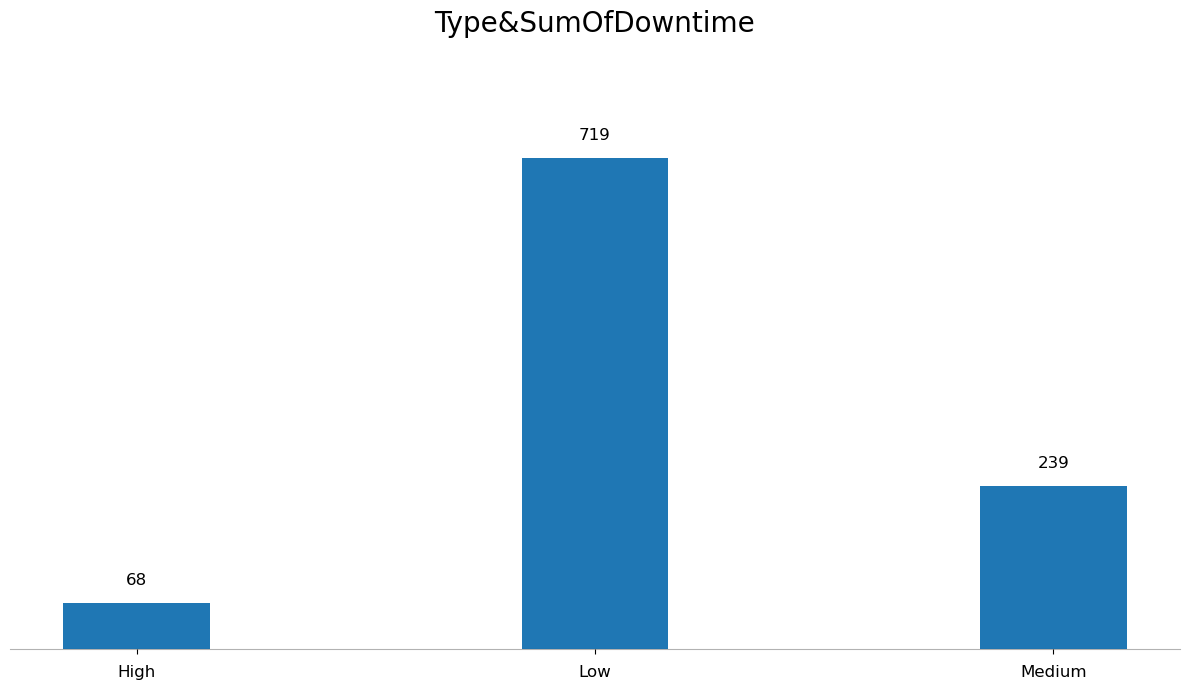

In [ ]:
# Calculate Sum of Downtime Hours by Type
downtime_analysis = (
    df_ai4i2020_fs
    .groupby("product_type", as_index=False)["downtime_hours"]
    .sum()
)

# Set exact category order
type_order = [
    "High",
    "Low",
    "Medium"
]

# Apply categorical order
downtime_analysis["product_type"] = pd.Categorical(
    downtime_analysis["product_type"],
    categories=type_order,
    ordered=True
)

# Sort categories
downtime_analysis = (
    downtime_analysis
    .sort_values("product_type")
    .reset_index(drop=True)
)

# Extract labels and actual values
labels = downtime_analysis["product_type"].astype(str)
values = downtime_analysis["downtime_hours"]

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart
bars = ax.bar(
    labels,
    values,
    width=0.32
)

# Add value labels above each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.03,
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

# Add chart title
ax.set_title(
    "Type and Sum of Downtime",
    fontsize=20,
    pad=20
)

# Hide Y-axis ticks and labels
ax.set_yticks([])

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Remove grid
ax.grid(False)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis line lighter
ax.spines["bottom"].set_alpha(0.3)

# Add space above bars for labels
ax.set_ylim(
    0,
    values.max() * 1.20
)

# Format X-axis labels
ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

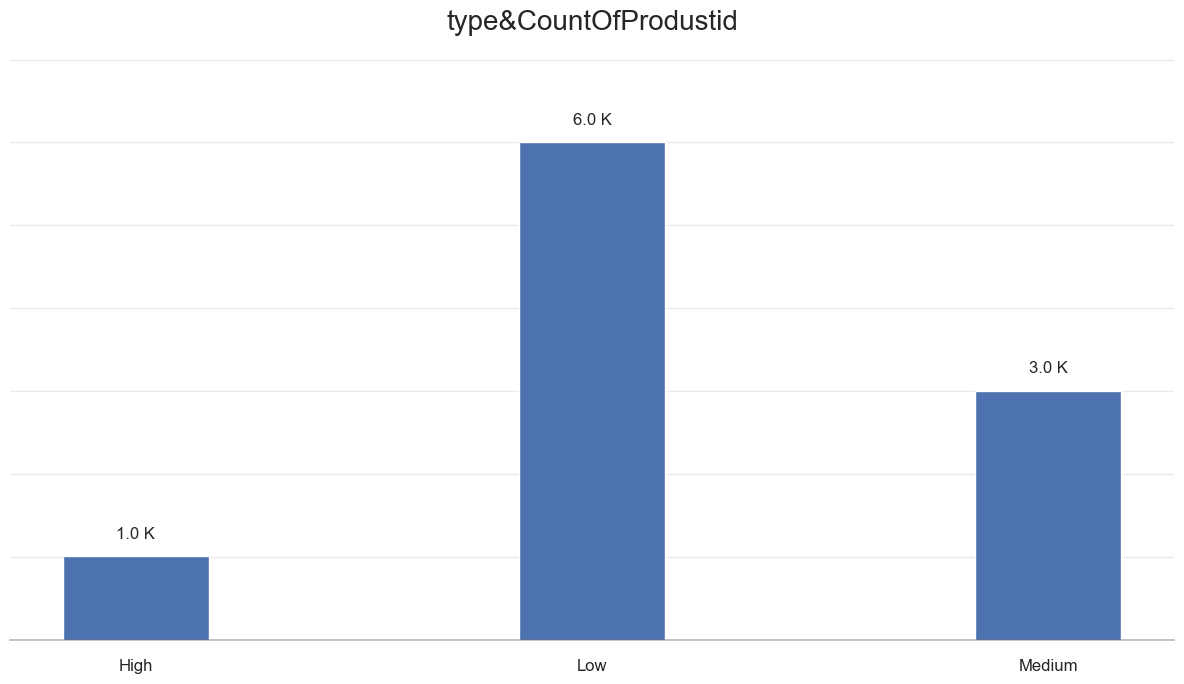

In [ ]:
# Count Product IDs by Type
product_count_analysis = (
    df_ai4i2020
    .groupby("product_type", as_index=False)["product_id"]
    .count()
)

# Set exact category order
type_order = [
    "High",
    "Low",
    "Medium"
]

# Apply categorical order
product_count_analysis["product_type"] = pd.Categorical(
    product_count_analysis["product_type"],
    categories=type_order,
    ordered=True
)

# Sort categories
product_count_analysis = (
    product_count_analysis
    .sort_values("product_type")
    .reset_index(drop=True)
)

# Extract labels and actual values
labels = product_count_analysis["product_type"].astype(str)
values = product_count_analysis["product_id"]

# Function to format values as K
def format_count(value):
    if value >= 1000:
        return f"{value / 1000:.1f} K"
    return f"{value:.0f}"

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart
bars = ax.bar(
    labels,
    values,
    width=0.32
)

# Add value labels above each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.03,
        format_count(value),
        ha="center",
        va="bottom",
        fontsize=12
    )

# Add chart title
ax.set_title(
    "type&CountOfProdustid",
    fontsize=20,
    pad=20
)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Hide Y-axis labels but keep horizontal gridlines
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Add horizontal gridlines
ax.grid(
    axis="y",
    linestyle="-",
    linewidth=1,
    alpha=0.4
)

# Keep bars above gridlines
ax.set_axisbelow(True)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis line lighter
ax.spines["bottom"].set_alpha(0.3)

# Add space above tallest bar
ax.set_ylim(
    0,
    values.max() * 1.17
)

# Format X-axis labels
ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

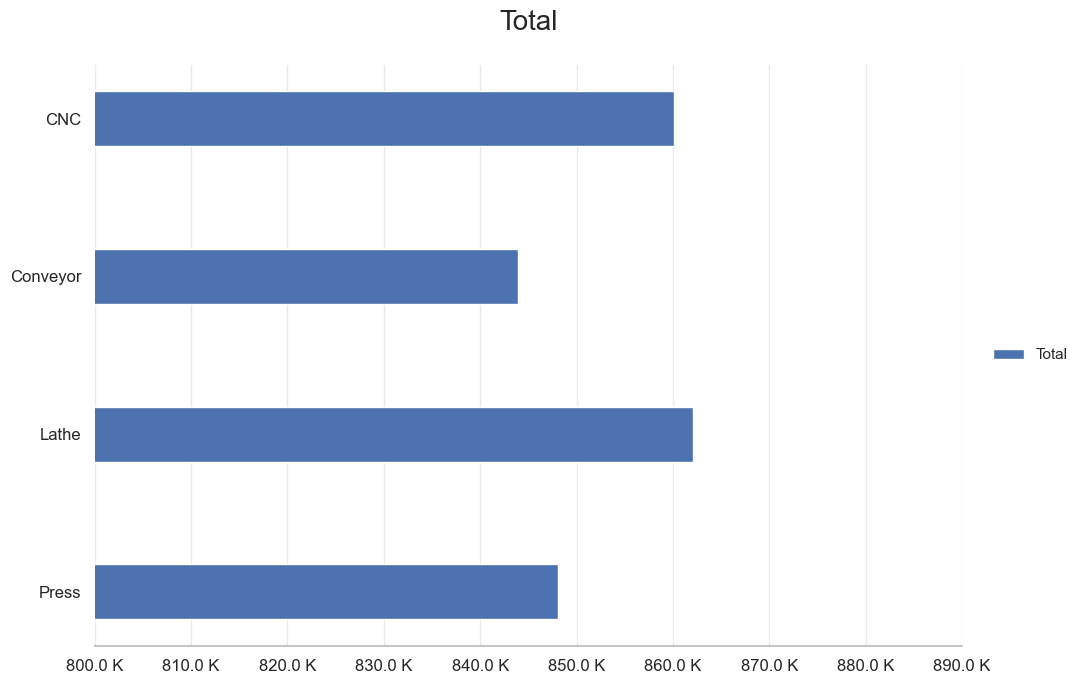

In [ ]:
# Calculate Sum of Production Units by Machine Type
machine_production_analysis = (
    df_ai4i2020_fs
    .groupby("machine_type", as_index=False)["production_units"]
    .sum()
)

# Set exact category order
machine_order = [
    "CNC",
    "Conveyor",
    "Lathe",
    "Press"
]

# Apply categorical order
machine_production_analysis["machine_type"] = pd.Categorical(
    machine_production_analysis["machine_type"],
    categories=machine_order,
    ordered=True
)

# Sort categories
machine_production_analysis = (
    machine_production_analysis
    .sort_values("machine_type")
    .reset_index(drop=True)
)

# Extract labels and actual values
labels = machine_production_analysis["machine_type"]
values = machine_production_analysis["production_units"]

# Create figure
fig, ax = plt.subplots(figsize=(11, 7))

# Create horizontal bar chart
ax.barh(
    labels,
    values,
    height=0.35,
    label="Total"
)

# Add chart title
ax.set_title(
    "Total",
    fontsize=20,
    pad=25
)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Format X-axis values as K
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x / 1000:.1f} K"
    )
)

# Set X-axis range similar to Excel chart
ax.set_xlim(
    800_000,
    890_000
)

# Add vertical gridlines
ax.grid(
    axis="x",
    linestyle="-",
    linewidth=1,
    alpha=0.4
)

# Keep bars above gridlines
ax.set_axisbelow(True)

# Reverse Y-axis to match the Excel chart:
# Press, Lathe, Conveyor, CNC
ax.invert_yaxis()

# Add legend on the right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis lighter
ax.spines["bottom"].set_alpha(0.3)

# Format tick labels
ax.tick_params(
    axis="both",
    labelsize=12
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

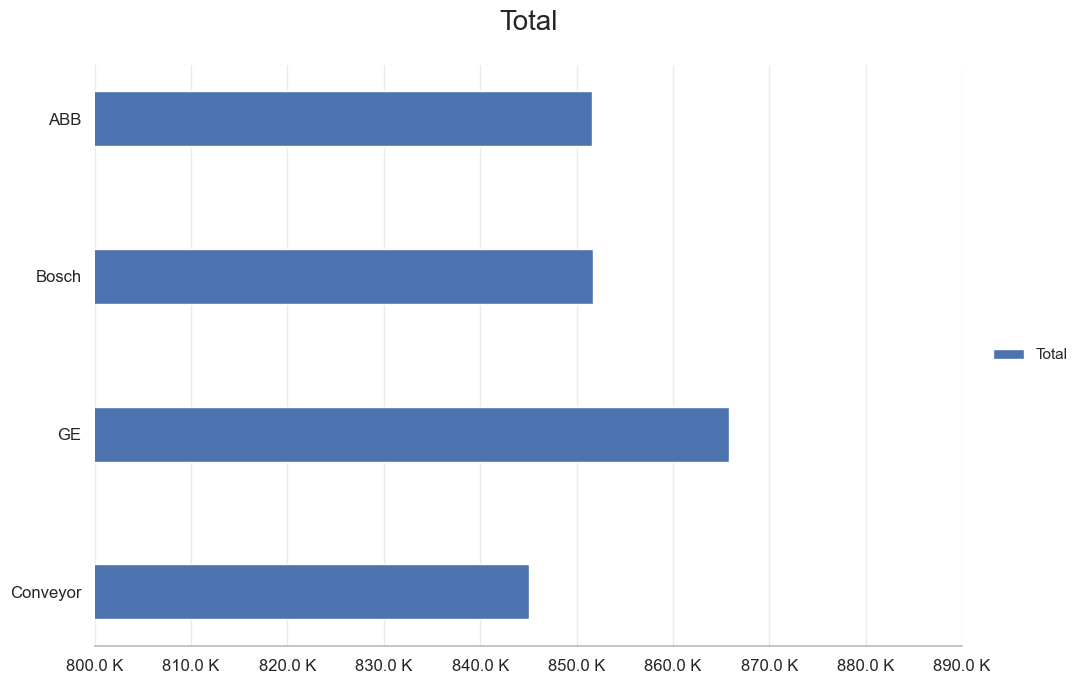

In [ ]:
# Calculate Sum of Production Units by Manufacturer
manufacturer_production_analysis = (
    df_ai4i2020_fs
    .groupby("brand", as_index=False)["production_units"]
    .sum()
)

# Replace Siemens with Conveyor
manufacturer_production_analysis["brand"] = (
    manufacturer_production_analysis["brand"]
    .replace("Siemens", "Conveyor")
)

# Set exact order
manufacturer_order = [
    "ABB",
    "Bosch",
    "GE",
    "Conveyor"
]

# Apply categorical order
manufacturer_production_analysis["brand"] = pd.Categorical(
    manufacturer_production_analysis["brand"],
    categories=manufacturer_order,
    ordered=True
)

# Sort categories
manufacturer_production_analysis = (
    manufacturer_production_analysis
    .sort_values("brand")
    .reset_index(drop=True)
)

# Extract labels and values
labels = manufacturer_production_analysis[
    "brand"
].astype(str)

values = manufacturer_production_analysis[
    "production_units"
]

# Create figure
fig, ax = plt.subplots(figsize=(11, 7))

# Create horizontal bar chart
ax.barh(
    labels,
    values,
    height=0.35,
    label="Total"
)

# Add chart title
ax.set_title(
    "Total",
    fontsize=20,
    pad=25
)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Format X-axis values as K
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x / 1000:.1f} K"
    )
)

# Set X-axis range
ax.set_xlim(
    800_000,
    890_000
)

# Add vertical gridlines
ax.grid(
    axis="x",
    linestyle="-",
    linewidth=1,
    alpha=0.4
)

ax.set_axisbelow(True)

# Reverse Y-axis
ax.invert_yaxis()

# Add legend
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Hide unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Make bottom axis lighter
ax.spines["bottom"].set_alpha(0.3)

# Format tick labels
ax.tick_params(
    axis="both",
    labelsize=12
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

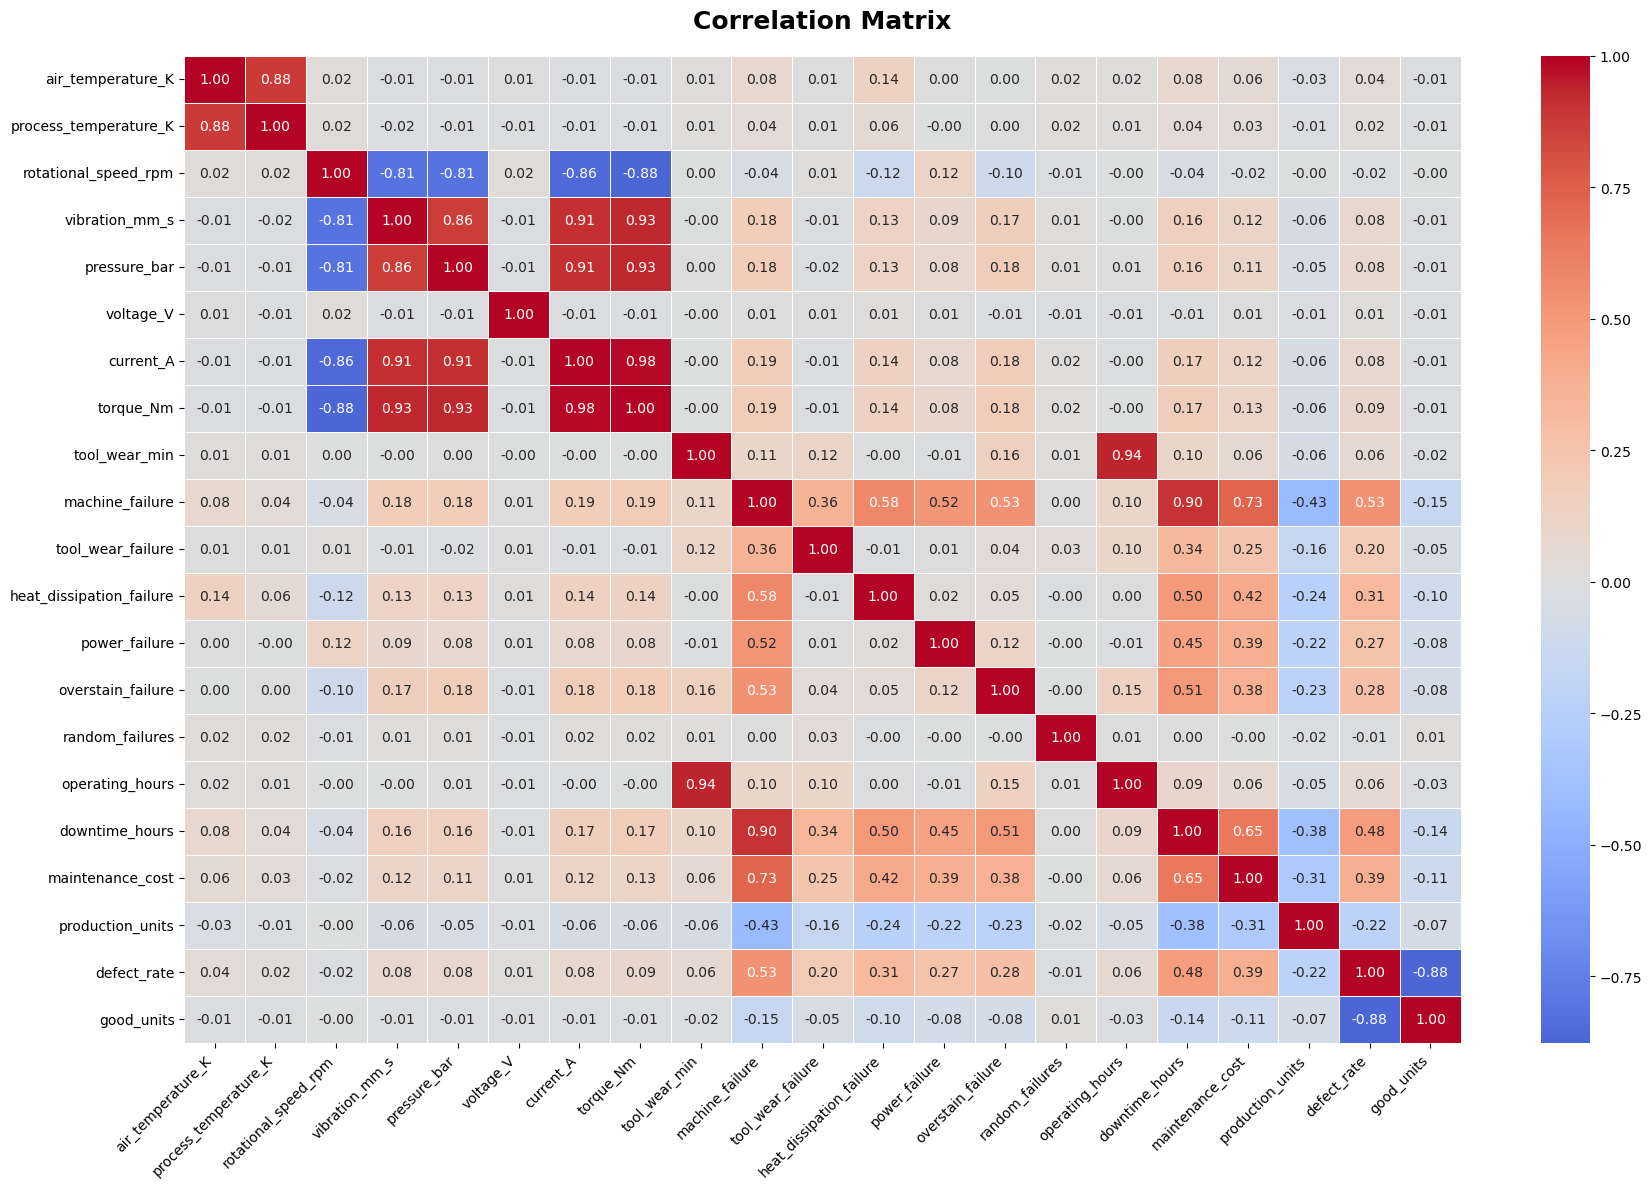

In [22]:
# Automatically select numeric columns
numeric_data = df_ai4i2020_fs.select_dtypes(
    include="number"
)

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Create heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()